In [14]:
# instalo las librerías que estimo necesarias para los análisis, para importar excel, 
# para gráficos y para mapas

%pip install pandas numpy matplotlib seaborn scipy openpyxl folium

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
# importo las librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium

sns.set(style="whitegrid")

In [16]:
# cargo el archivo

df = pd.read_excel("Sicilia.xlsx")

df.head()

,id,host_id,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,7011,16888,Marsala,37.83969,12.47949,Entire home/apt,219.0,3,32,2024-08-08,0.16,10,0,0,IT081011A1HJT5H6NW
1,22948,88837,Agrigento,37.30949,13.58569,Private room,45.0,1,458,2025-09-21,2.67,3,130,64,IT084001C1KUVGVHF9
2,35264,151644,Piedimonte Etneo,37.82461,15.15876,Entire home/apt,109.0,1,165,2025-09-15,0.89,5,361,7,IT087035B5VYN4LFLN
3,43992,192525,Erice,38.03442,12.53462,Entire home/apt,68.0,5,81,2025-09-11,0.53,2,103,11,IT081008C26PNHNIA6
4,43995,192525,San Vito Lo Capo,38.16904,12.74028,Entire home/apt,75.0,5,73,2025-08-16,0.46,2,322,6,IT081020C2NSGROBUN


In [17]:
# Análisis descriptivo básico

df.info()
df.describe()

df.isnull().sum()     # valores vacíos
df.nunique()          # valores únicos

<class 'pandas.DataFrame'>
RangeIndex: 31829 entries, 0 to 31828
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              31829 non-null  int64         
 1   host_id                         31829 non-null  int64         
 2   neighbourhood                   31829 non-null  str           
 3   latitude                        31829 non-null  float64       
 4   longitude                       31829 non-null  float64       
 5   room_type                       31829 non-null  str           
 6   price                           29768 non-null  float64       
 7   minimum_nights                  31829 non-null  int64         
 8   number_of_reviews               31829 non-null  int64         
 9   last_review                     26003 non-null  datetime64[us]
 10  reviews_per_month               26003 non-null  float64       
 11  calculated_ho

id                                31829
host_id                           22296
neighbourhood                       356
latitude                          28913
longitude                         29191
room_type                             4
price                               900
minimum_nights                       24
number_of_reviews                   468
last_review                        1511
reviews_per_month                   693
calculated_host_listings_count       76
availability_365                    366
number_of_reviews_ltm               106
license                           31828
dtype: int64

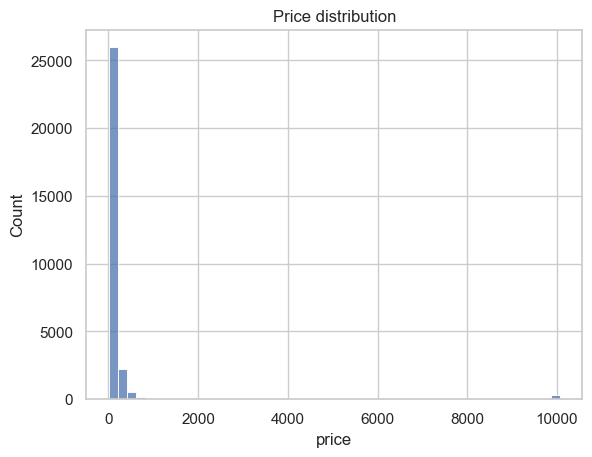

In [18]:
# distribución de precios

sns.histplot(df["price"], bins=50)
plt.title("Price distribution")
plt.show()

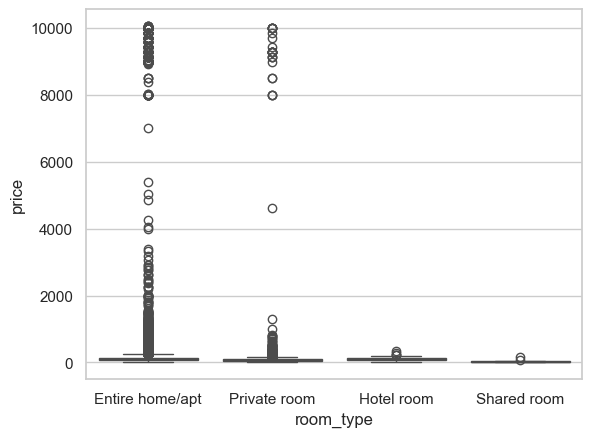

In [19]:
# precios por tipo de habitación

sns.boxplot(x="room_type", y="price", data=df)
plt.show()

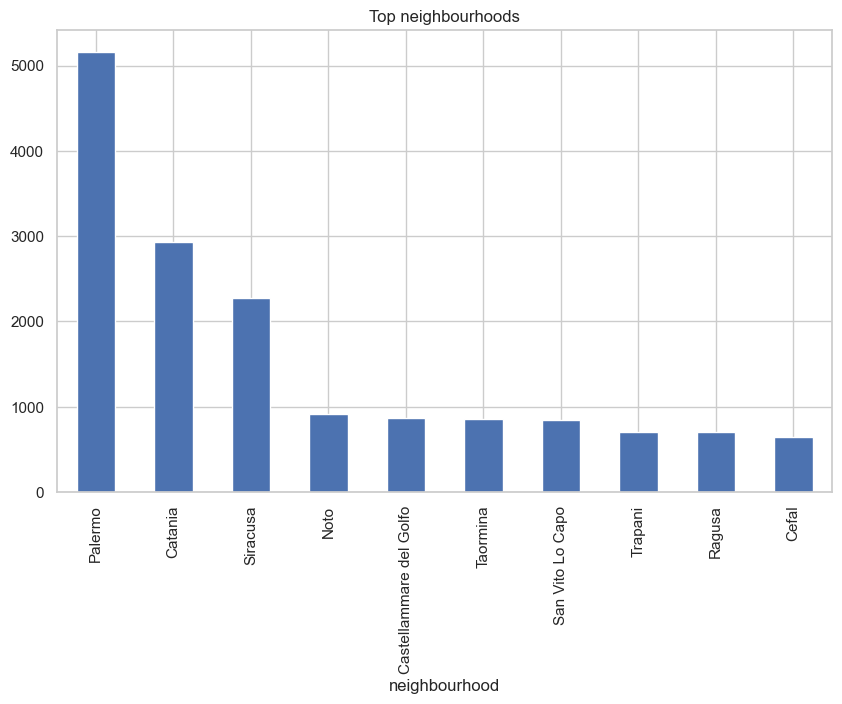

In [20]:
# distribusión por vecindario

plt.figure(figsize=(10,6))
df["neighbourhood"].value_counts().head(10).plot(kind="bar")
plt.title("Top neighbourhoods")
plt.show()

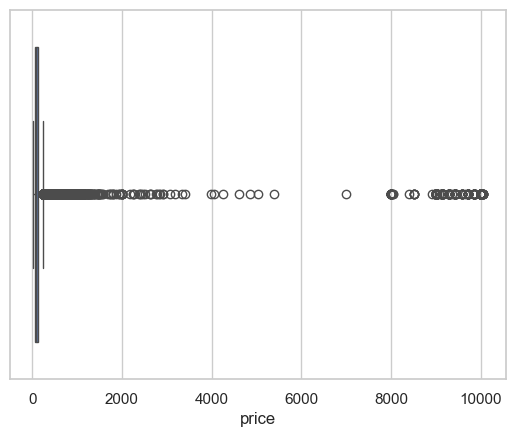

In [21]:
# revisamos outliers de precios

sns.boxplot(x=df["price"])
plt.show()

In [22]:
# revisamos las correlaciones de las variables numéricas que nos interesa analizar

num_vars = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "number_of_reviews_ltm"
]

num_df = df[num_vars]

corr = df.corr(numeric_only=True)

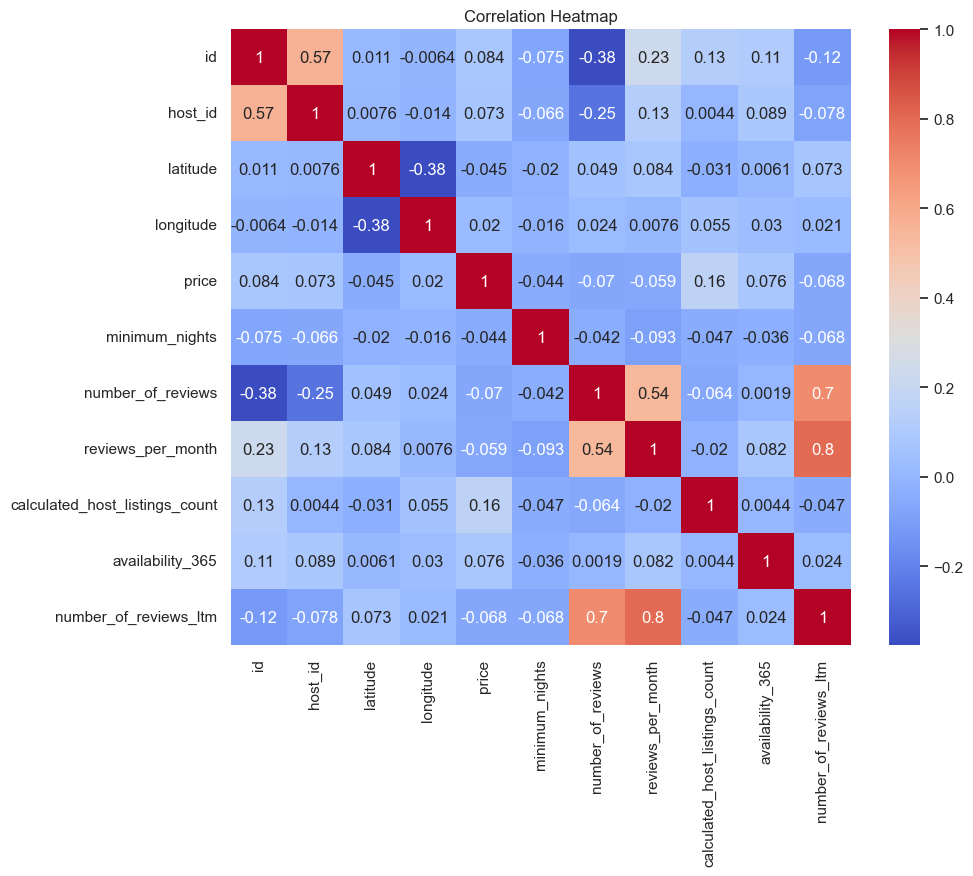

In [23]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

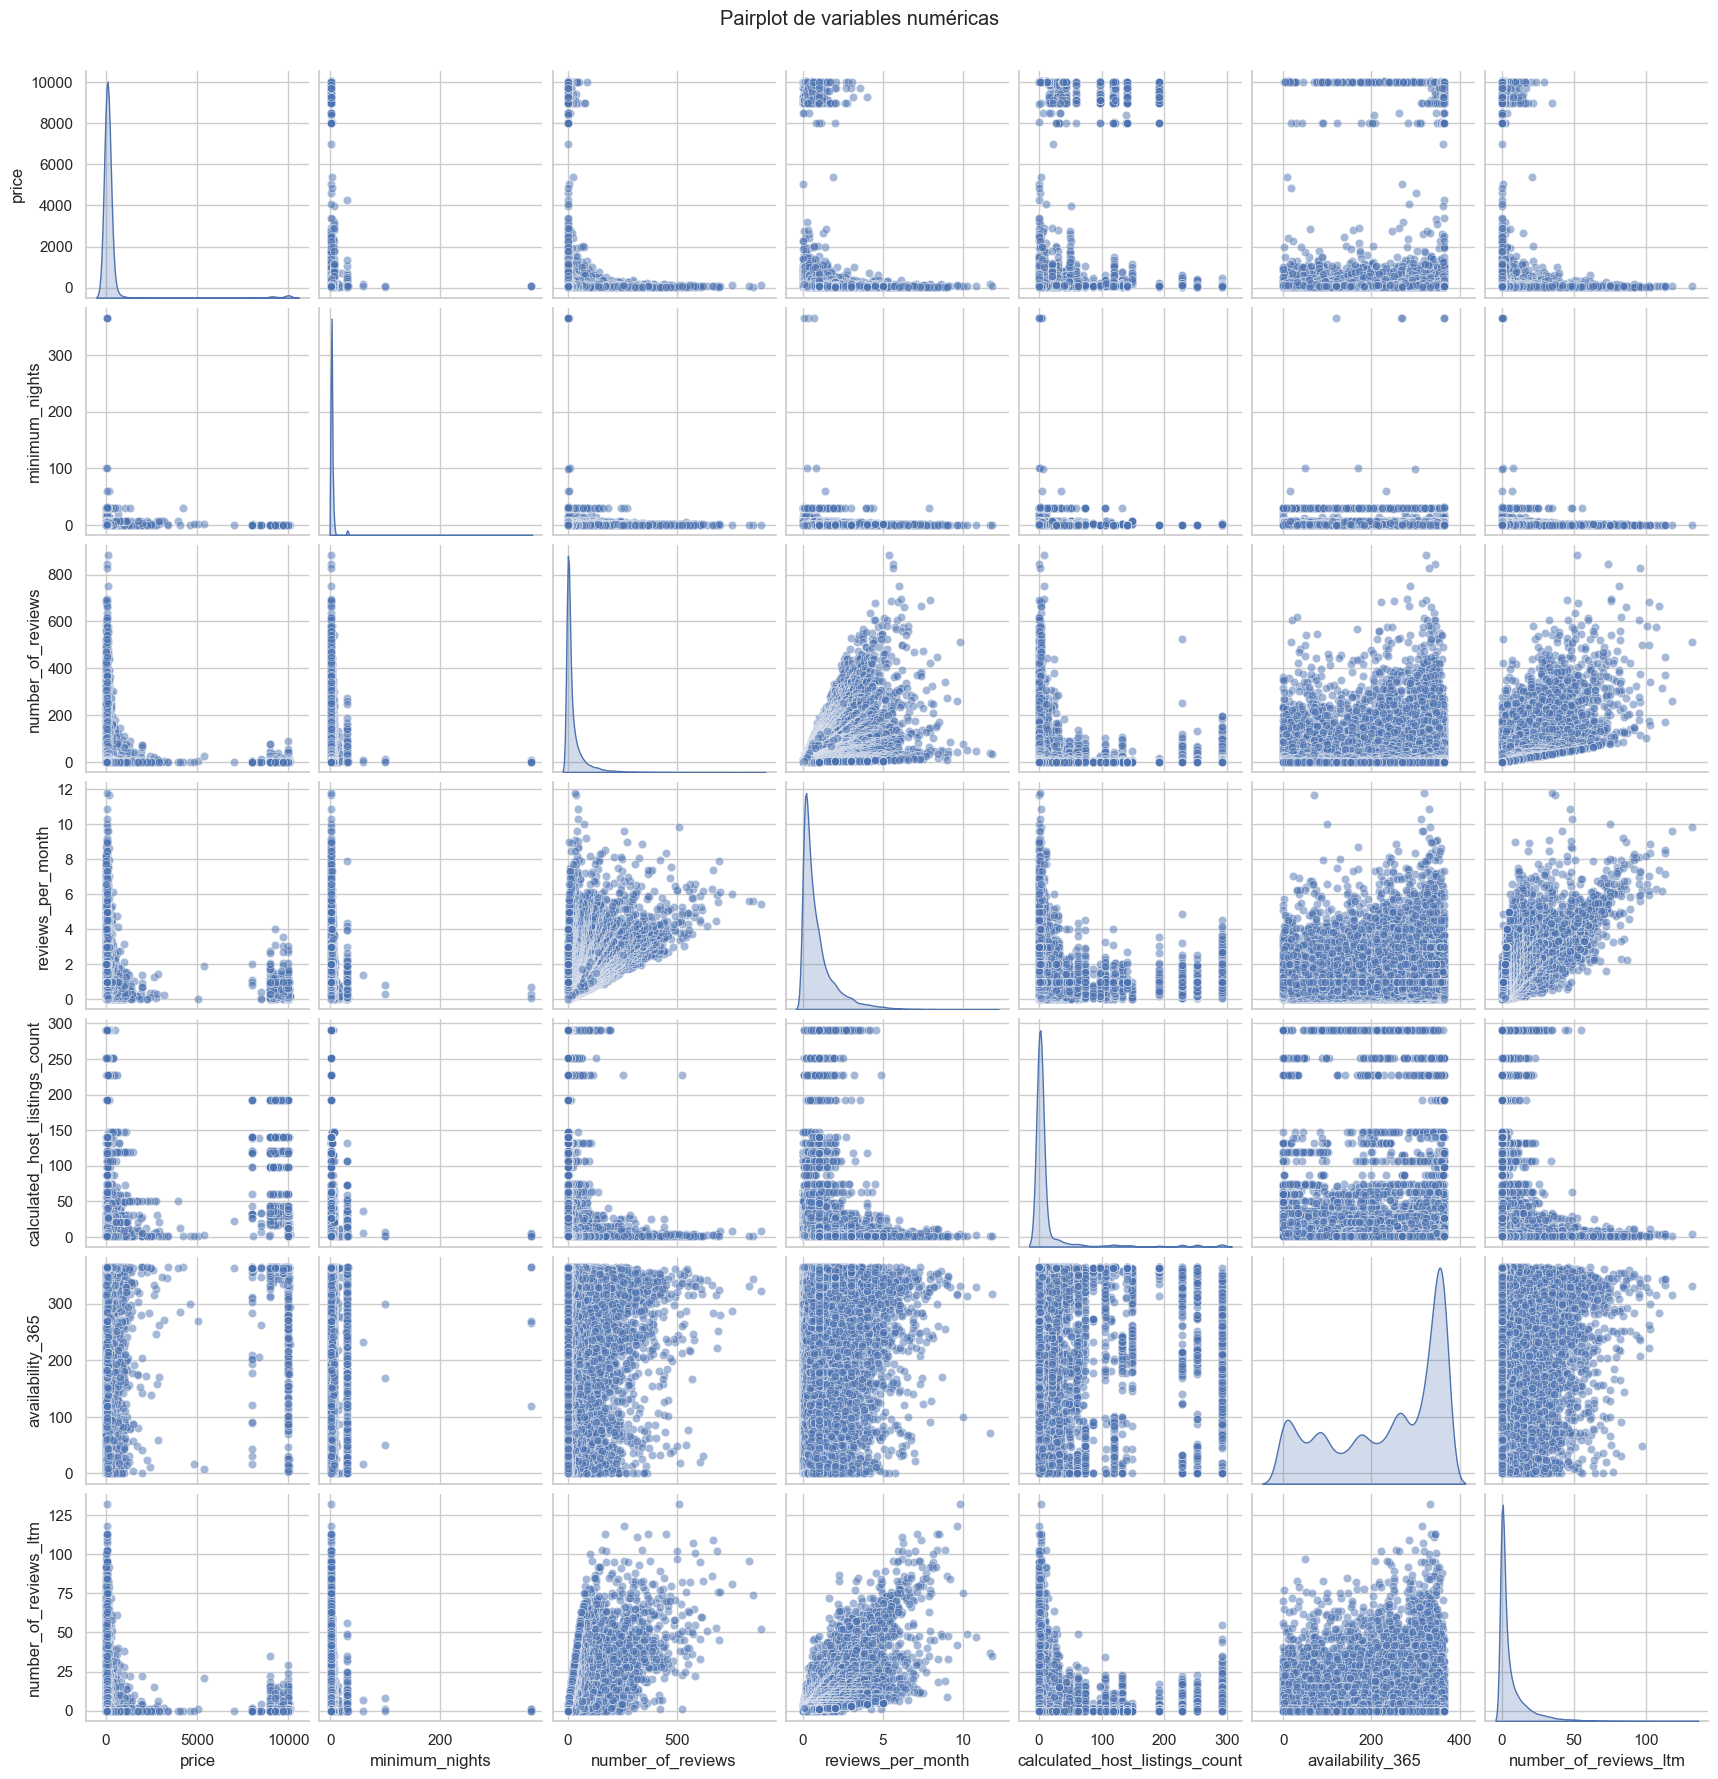

In [24]:
# pairplot adaptado

sns.pairplot(
    num_df,
    kind="scatter",       # gráfico principal de dispersión
    diag_kind="kde",      # para ver la distribución de cada variable en la diagonal
    plot_kws={"alpha":0.5},  # transparencia para que se vean mejor densidades
    height=2.5            # tamaño de cada subplot
)
plt.suptitle("Pairplot de variables numéricas", y=1.02)
plt.show()

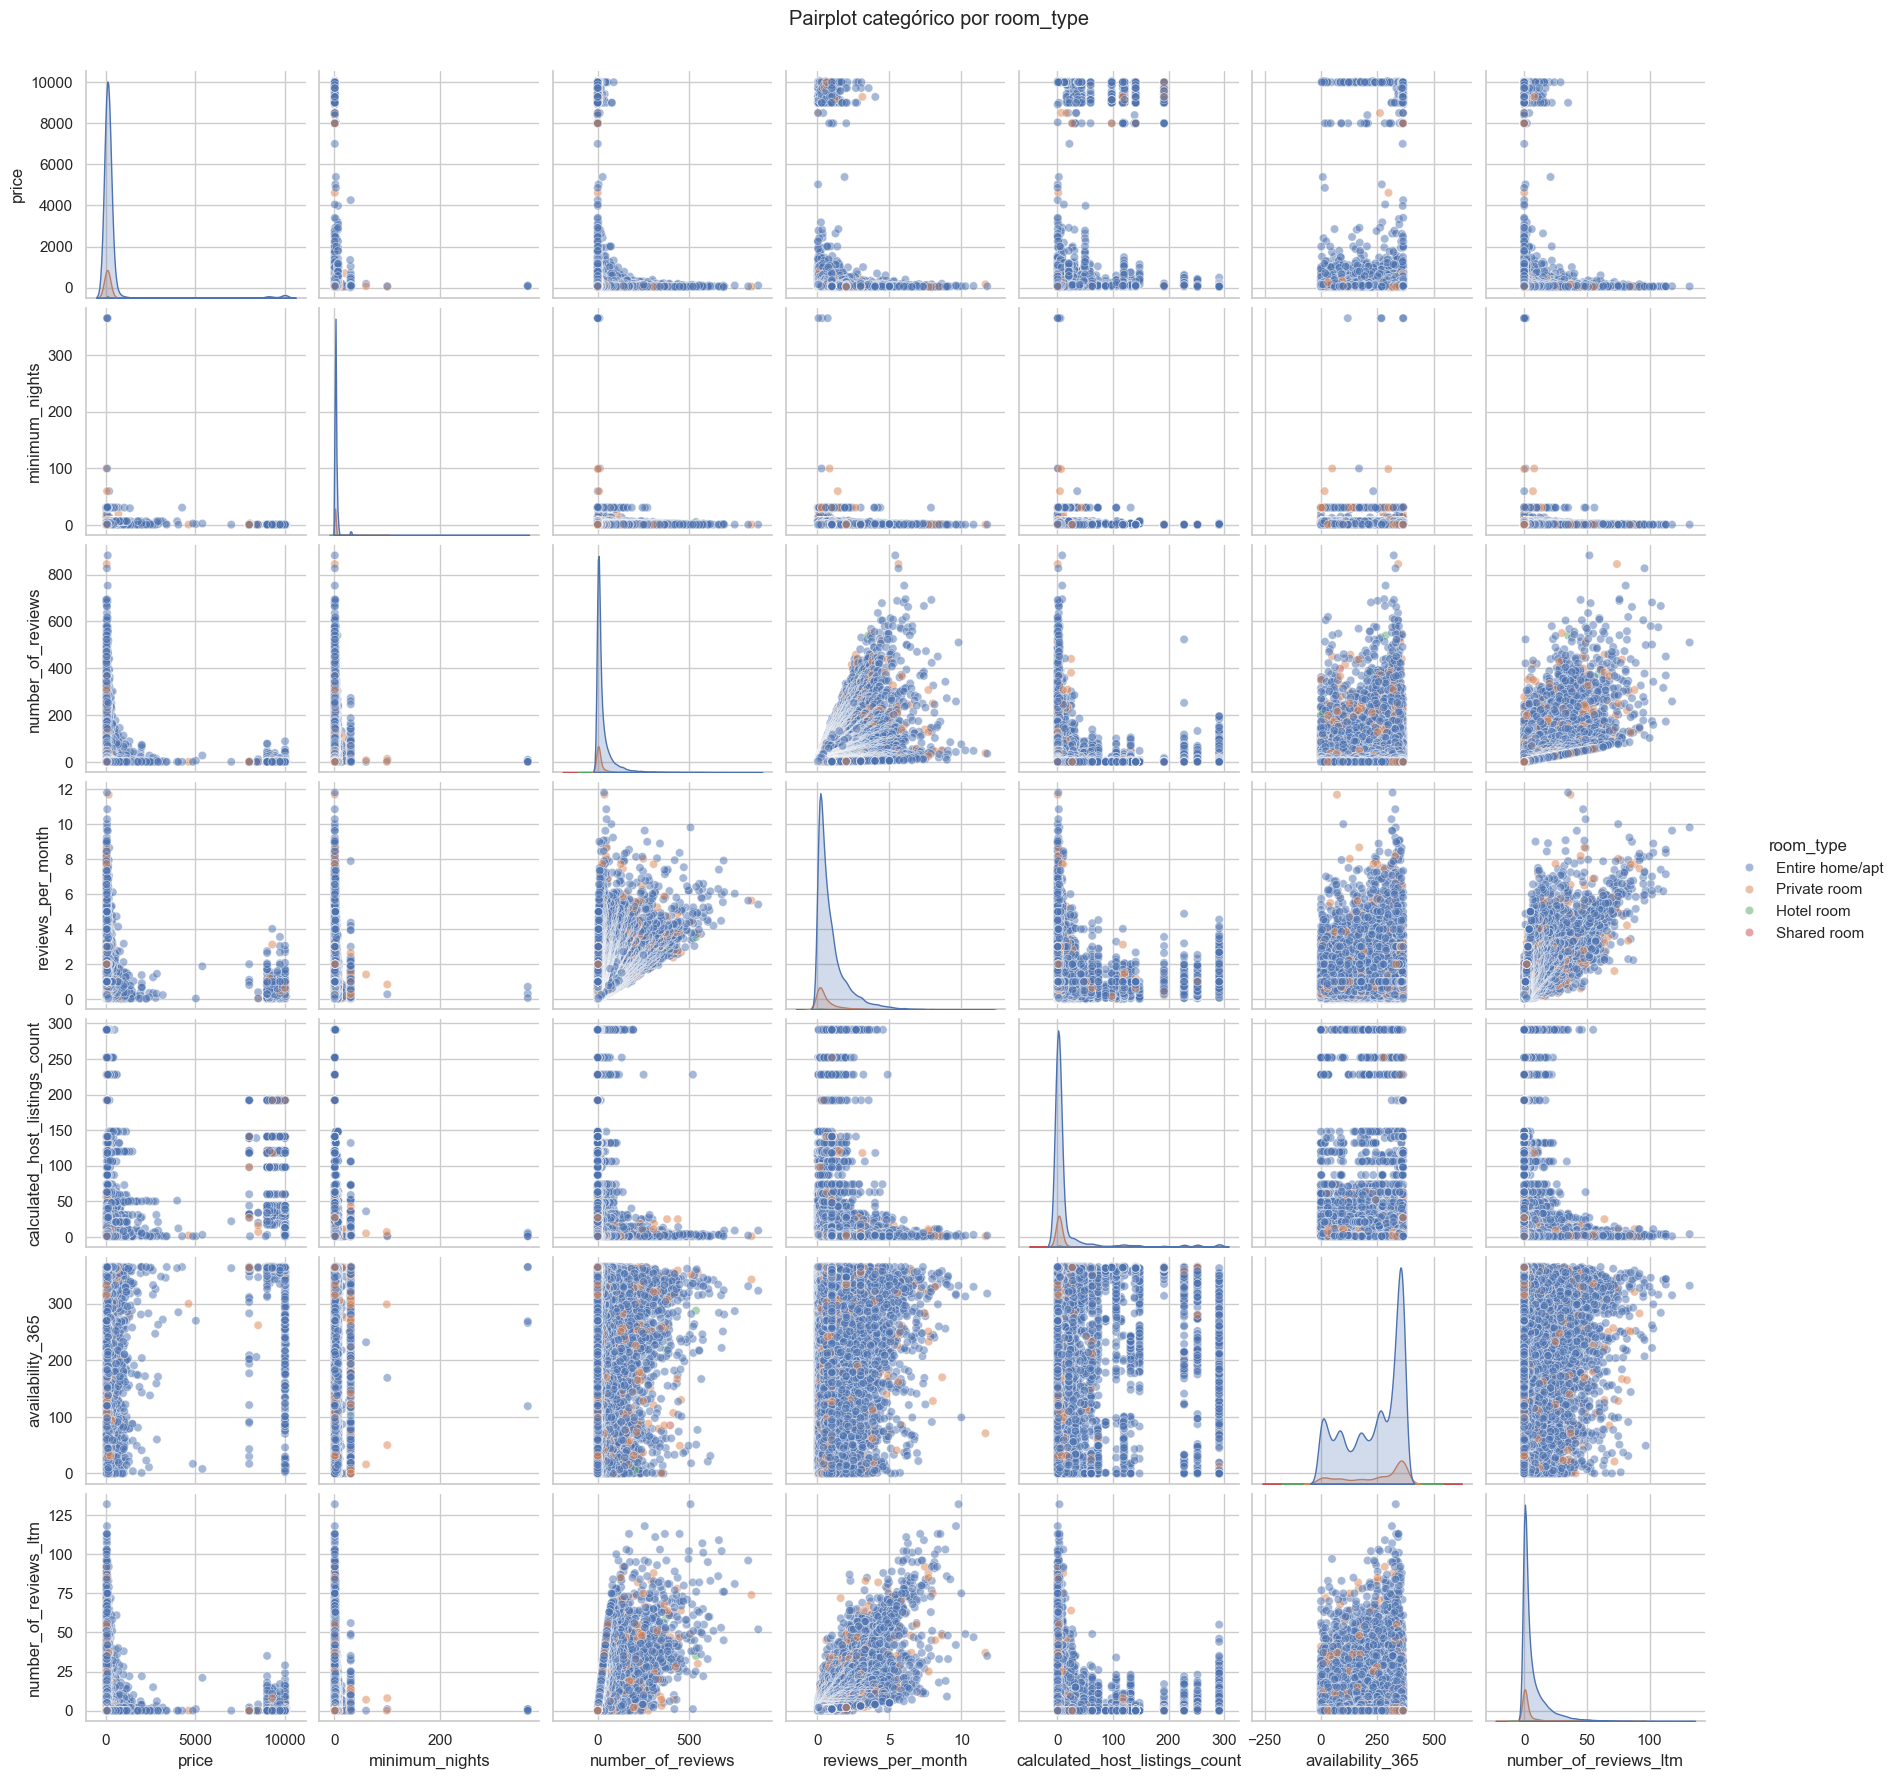

In [25]:
# creamos dataFrame para pairplot y así ver si ciertas variables dependen del tipo de habitación

num_df = df[num_vars + ["room_type"]]  # añadimos la columna categórica

sns.pairplot(
    num_df,
    hue="room_type",      # color según tipo de habitación
    diag_kind="kde",      # distribución en la diagonal
    kind="scatter",       # scatter plots fuera de la diagonal
    plot_kws={"alpha":0.5}, # transparencia
    height=2.5
)
plt.suptitle("Pairplot categórico por room_type", y=1.02)
plt.show()

In [26]:
# creamos el mapa centrado en el promedio de coordenadas

map_airbnb = folium.Map(
    location=[df["latitude"].mean(), df["longitude"].mean()],
    zoom_start=12
)

map_airbnb